In [21]:
!pip install scikit_learn
!pip install pandas
!pip install numpy
!pip install matplotlib.pyplot
!pip install seaborn
!pip install pickle


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [22]:
import pandas as pd
import numpy as np
import pickle 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("age_cursor_data.CSV")
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Participant   88 non-null     int64  
 1   Age           88 non-null     int64  
 2   Gender        88 non-null     int64  
 3   hand          88 non-null     str    
 4   PorsuitRotor  88 non-null     float64
 5   SimpleRT      88 non-null     float64
 6   dailymouse    88 non-null     int64  
 7   Group         88 non-null     str    
dtypes: float64(2), int64(4), str(2)
memory usage: 5.6 KB


### The values in the dataset

This dataset measures the change in motor skills as age progresses from 18 to 68.

It uses 2 key metrics:


*   Porsuit Rotor: participants try to follow a moving object with their cursor. The higher the value, the higher the proportion of time spent on the target, higher their motor skills.

*   Simple RT: participants press a button as soon as a stimulus arrives. This means their reaction time. A lower reaction means higher motor skills.



In [9]:
df.drop(columns = ["Gender", "hand", "Participant", "dailymouse"], inplace = True)
df.head()

,Age,PorsuitRotor,SimpleRT,Group
0,18,0.823950,391.677966,Young
1,19,0.664125,318.559322,Young
2,19,0.776000,304.661017,Young
3,19,0.831200,356.864407,Young
4,19,0.916225,306.431035,Young


In [10]:
df = df[df['Age'] >= 50]
df.info()

<class 'pandas.DataFrame'>
Index: 27 entries, 54 to 87
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           27 non-null     int64  
 1   PorsuitRotor  27 non-null     float64
 2   SimpleRT      27 non-null     float64
 3   Group         27 non-null     str    
dtypes: float64(2), int64(1), str(1)
memory usage: 1.1 KB


In [25]:
def engineer_features(df):

    # 1. Inverse of PursuitRotor (higher = worse performance)
    df_engineered = df.copy()
    df_engineered['PursuitRotor_Inverse'] = 1 - df_engineered['PorsuitRotor']

    # 2. RT to Accuracy Ratio (combined performance metric)
    df_engineered['RT_to_Accuracy_Ratio'] = (
        df_engineered['SimpleRT'] / (df_engineered['PorsuitRotor'] + 0.001)
    )

    # 3. Normalize RT (standardized reaction time)
    df_engineered['SimpleRT_Normalized'] = (
        (df_engineered['SimpleRT'] - df_engineered['SimpleRT'].mean()) /
        df_engineered['SimpleRT'].std()
    )

    # 4. Composite Impairment Score
    # Combination of poor tracking + slow RT
    df_engineered['Impairment_Score'] = (
        (1 - df_engineered['PorsuitRotor']) *
        (df_engineered['SimpleRT'] / df_engineered['SimpleRT'].mean())
    )

    # 5. Binary features (thresholds based on median)
    df_engineered['Low_Accuracy'] = (
        df_engineered['PorsuitRotor'] < df_engineered['PorsuitRotor'].median()
    ).astype(int)

    df_engineered['High_RT'] = (
        df_engineered['SimpleRT'] > df_engineered['SimpleRT'].median()
    ).astype(int)

    # 6. Squared features (capture non-linear relationships)
    df_engineered['PursuitRotor_Squared'] = df_engineered['PorsuitRotor'] ** 2
    df_engineered['SimpleRT_Squared'] = df_engineered['SimpleRT'] ** 2
    

    return df_engineered

feature_params = {
    "SimpleRT_mean": df['SimpleRT'].mean(),
    "SimpleRT_std": df['SimpleRT'].std(),
    "PorsuitRotor_median": df['PorsuitRotor'].median(),
    "SimpleRT_median": df['SimpleRT'].median()
}

import pickle
with open("feature_params.pkl", "wb") as f:
    pickle.dump(feature_params, f)



In [ ]:
def prepare_ml_data(df, use_engineered_features=True):
    """Prepare features and target for ML"""


    # Convert target to binary (0 = Young/No Impairment, 1 = Older/Impairment)
    df['Target'] = (df['Group'] == 'Older').astype(int)

    # Select features
    if use_engineered_features:
        # Exclude only non-feature columns
        feature_cols = [col for col in df.columns
                       if col not in ['Group', 'Target', 'Age']]
    else:
        # Use only original features
        feature_cols = ['PorsuitRotor', 'SimpleRT']

    X = df[feature_cols]
    y = df['Target']

    print(f"\nFeatures used: {feature_cols}")
    print(f"Feature matrix shape: {X.shape}")
    print(f"Target distribution: {y.value_counts().to_dict()}")

    return X, y, feature_cols

In [13]:
# Random forest training
def train_random_forest(X_train, y_train, X_test, y_test, optimize=True):
  """Train Random Forest with optional hyperparameter tuning"""

  if optimize:
      print("\nPerforming hyperparameter tuning...")
      # Grid search for best parameters
      param_grid = {
          'n_estimators': [50, 100, 200],
          'max_depth': [None, 10, 20, 30],
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 2, 4],
          'max_features': ['sqrt', 'log2']
      }

      rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
      grid_search = GridSearchCV(
          rf_base,
          param_grid,
          cv=5,
          scoring='f1',
          n_jobs=-1,
          verbose=1
      )
      grid_search.fit(X_train, y_train)

      print(f"\nBest parameters: {grid_search.best_params_}")
      print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

      rf_model = grid_search.best_estimator_
  else:
      print("\nTraining with default parameters...")
      rf_model = RandomForestClassifier(
          n_estimators=100,
          max_depth=None,
          min_samples_split=2,
          min_samples_leaf=1,
          random_state=42,
          class_weight='balanced'
      )
      rf_model.fit(X_train, y_train)

  # Cross-validation scores
  cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
  print(f"\nCross-validation F1 scores: {cv_scores}")
  print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

  return rf_model

In [14]:
def evaluate_model(model, X_train, y_train, X_test, y_test, feature_names):
    """Comprehensive model evaluation"""

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    print("\n--- TRAINING SET PERFORMANCE ---")
    print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"F1 Score: {f1_score(y_train, y_train_pred):.4f}")

    print("\n--- TEST SET PERFORMANCE ---")
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_test_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_test_pred,
                                target_names=['No Impairment', 'Impairment']))

    print("\n--- CONFUSION MATRIX ---")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    print(f"\nTrue Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives: {cm[1,1]}")

    # Feature importance
    print("\n--- FEATURE IMPORTANCE ---")
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(feature_importance.to_string(index=False))

    return {
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba,
        'feature_importance': feature_importance,
        'confusion_matrix': cm
    }

In [15]:
def create_visualizations(results, feature_importance):
    """Create comprehensive visualizations"""
    fig = plt.figure(figsize=(16, 12))

    # 1. Confusion Matrix
    ax1 = plt.subplot(2, 3, 1)
    sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Impairment', 'Impairment'],
                yticklabels=['No Impairment', 'Impairment'])
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # 2. ROC Curve
    ax2 = plt.subplot(2, 3, 2)
    fpr, tpr, _ = roc_curve(results['y_test'], results['y_test_proba'])
    auc = roc_auc_score(results['y_test'], results['y_test_proba'])
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 3. Precision-Recall Curve
    ax3 = plt.subplot(2, 3, 3)
    precision, recall, _ = precision_recall_curve(results['y_test'], results['y_test_proba'])
    plt.plot(recall, precision, linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # 4. Feature Importance (Top 10)
    ax4 = plt.subplot(2, 3, 4)
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    # 5. Prediction Distribution
    ax5 = plt.subplot(2, 3, 5)
    plt.hist(results['y_test_proba'][results['y_test'] == 0],
             bins=20, alpha=0.5, label='No Impairment', color='blue')
    plt.hist(results['y_test_proba'][results['y_test'] == 1],
             bins=20, alpha=0.5, label='Impairment', color='red')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold')

    # 6. Class Balance
    ax6 = plt.subplot(2, 3, 6)
    class_counts = pd.Series(results['y_test']).value_counts()
    plt.bar(['No Impairment', 'Impairment'],
            [class_counts[0], class_counts[1]],
            color=['blue', 'red'], alpha=0.6)
    plt.ylabel('Count')
    plt.title('Test Set Class Distribution', fontsize=14, fontweight='bold')
    for i, v in enumerate([class_counts[0], class_counts[1]]):
        plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    plt.tight_layout()


    return fig

In [16]:
def generate_recommendations(feature_importance):
    """Generate recommendations based on feature importance"""

    top_5 = feature_importance.head(5)
    for idx, row in top_5.iterrows():
        importance_pct = row['Importance'] * 100
        print(f"\n{idx + 1}. {row['Feature']}")
        print(f"   Importance: {importance_pct:.2f}%")

        # Provide interpretation
        if 'PorsuitRotor' in row['Feature'] or 'Accuracy' in row['Feature']:
            print("   → Measures cursor tracking accuracy")
            print("   → Lower values indicate motor control difficulties")
        elif 'SimpleRT' in row['Feature'] or 'RT' in row['Feature']:
            print("   → Measures reaction time")
            print("   → Higher values indicate slower motor responses")
        elif 'Impairment_Score' in row['Feature']:
            print("   → Composite metric combining accuracy and reaction time")
            print("   → Higher values indicate higher likelihood of impairment")
        elif 'Ratio' in row['Feature']:
            print("   → Relationship between reaction time and accuracy")
            print("   → Useful for detecting coordination issues")


PREPARING DATA FOR MACHINE LEARNING

Features used: ['PorsuitRotor', 'SimpleRT', 'PursuitRotor_Inverse', 'RT_to_Accuracy_Ratio', 'SimpleRT_Normalized', 'Impairment_Score', 'Low_Accuracy', 'High_RT', 'PursuitRotor_Squared', 'SimpleRT_Squared']
Feature matrix shape: (88, 10)
Target distribution: {0: 54, 1: 34}

Training set: 61 samples
Test set: 27 samples

Training with default parameters...

Cross-validation F1 scores: [0.88888889 0.66666667 1.         1.         0.90909091]
Mean CV F1: 0.8929 (+/- 0.2440)

--- TRAINING SET PERFORMANCE ---
Accuracy: 1.0000
F1 Score: 1.0000

--- TEST SET PERFORMANCE ---
Accuracy: 0.9259
F1 Score: 0.9000
ROC-AUC: 0.9882

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

No Impairment       0.94      0.94      0.94        17
   Impairment       0.90      0.90      0.90        10

     accuracy                           0.93        27
    macro avg       0.92      0.92      0.92        27
 weighted avg       0.93      0

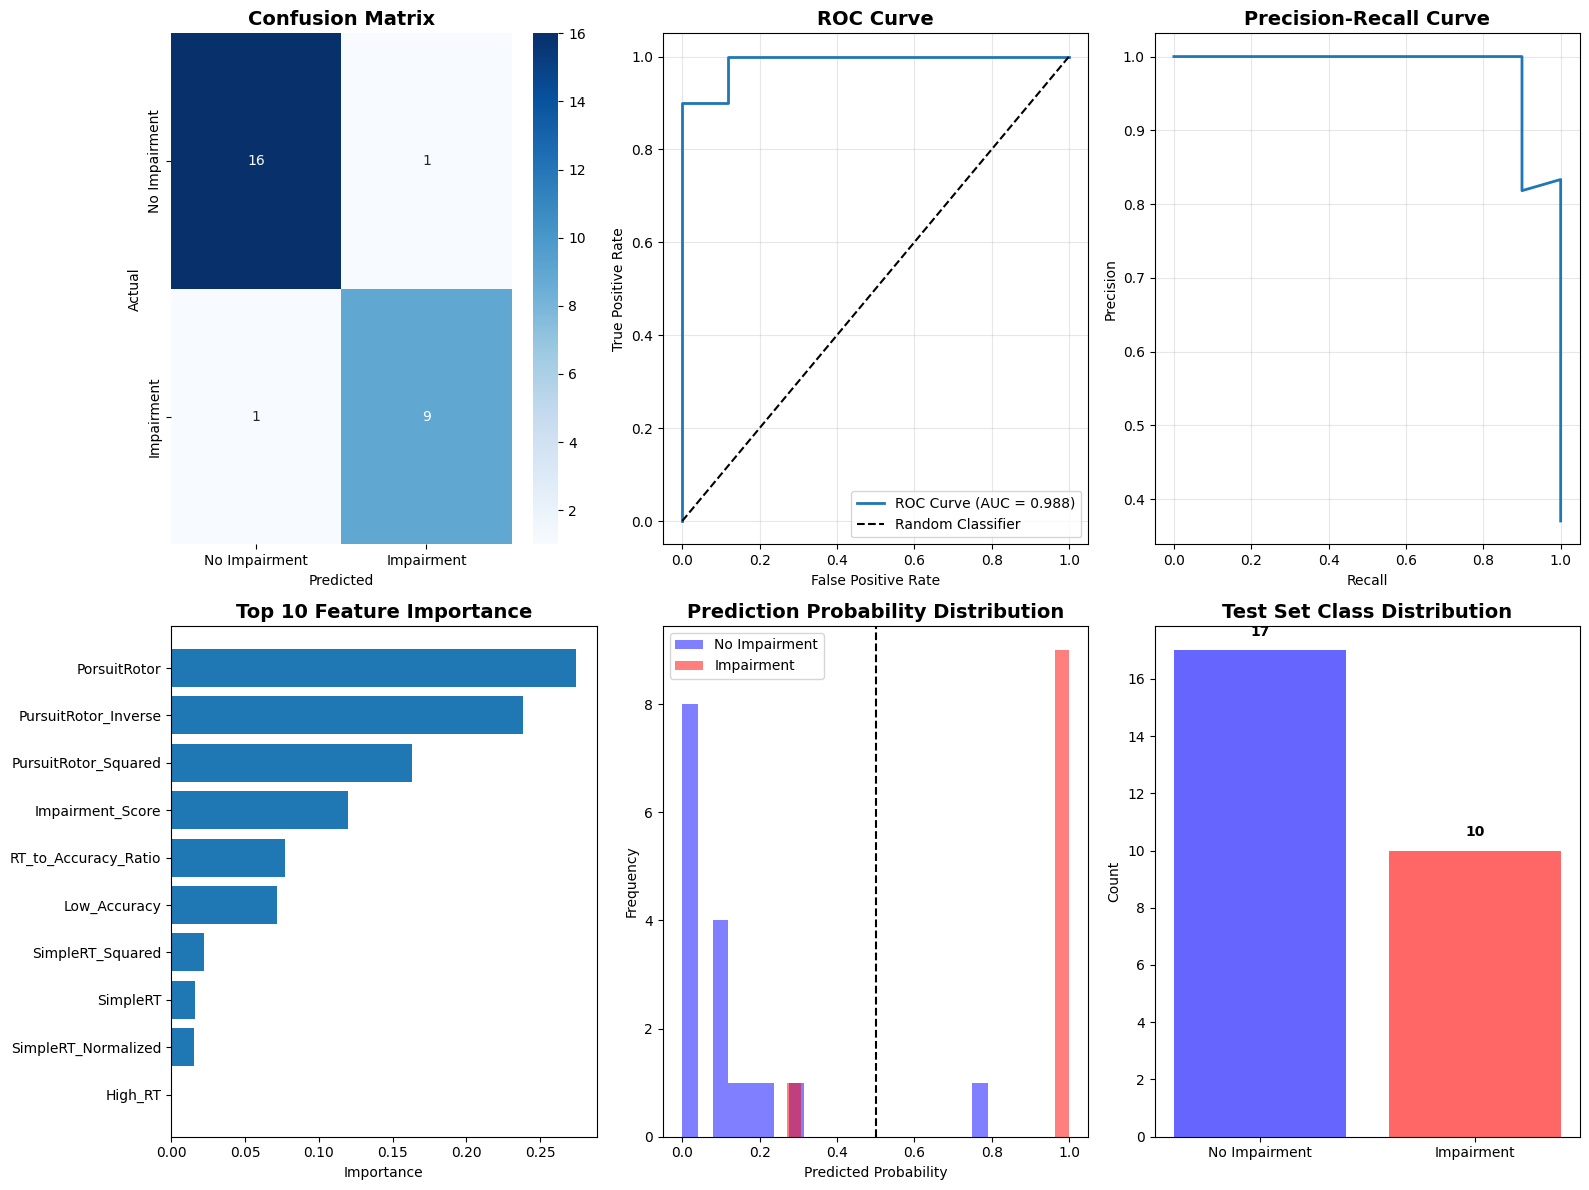

In [24]:
def main():
    """Main execution pipeline"""
    initial_df = pd.read_csv("age_cursor_data.CSV")
    initial_df.dropna(inplace=True)
    # Apply relevant preprocessing steps from previous cells that are not causing the issue.
    # From cell VzxutG8Q_R9y
    initial_df.drop(columns = ["Gender", "hand", "Participant", "dailymouse"], inplace = True)


    # Now, initial_df should contain both 'Young' and 'Older' groups
    # Pass this correctly prepared DataFrame to the feature engineering function
    df_engineered = engineer_features(initial_df)

    # Step 3: Prepare ML data
    X, y, feature_names = prepare_ml_data(df_engineered, use_engineered_features=True)

    # Check if 'y' still contains only one unique class after preparation
    # This check is crucial for robust classification setup
    if y.nunique() < 2:
        print("\nERROR: Target variable 'y' contains only one unique class after data preparation.")
        print("Binary classification cannot proceed. Please ensure the dataset contains at least two target classes.")
        return None, None # Exit if classification is not possible

    # Step 4: Train-test split

    # Stratification requires at least two samples per class in the target variable.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"\nTraining set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Step 5: Train model
    model = train_random_forest(X_train, y_train, X_test, y_test, optimize=False)

    # Step 6: Evaluate model
    results = evaluate_model(model, X_train, y_train, X_test, y_test, feature_names)

    # Step 7: Create visualizations
    create_visualizations(results, results['feature_importance'])

    # Step 8: Generate recommendations
    generate_recommendations(results['feature_importance'])

    print("\nOutputs generated: detailed metrics & recommendations")

    return model, results


if __name__ == "__main__":
    model, results = main()
    
    with open('model.pkl', 'wb') as f:
        pickle.dump(model, f)

From the analysis, Porsuit Rotor seems to be the most important factor in determining whether an user might have motor impairment.